# Project 3: Correlation Heatmap & Pairwise Relationships

**Name:** Sujal Kalamkar

**Internship:** SyntecxHub Data Science Internship

**Objective:**
Calculate Pearson correlations across numeric features, visualize them using a heatmap, explore pairwise relationships with scatter plots, and summarize the strongest positive and negative correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# Generate sample dataset

n = 300

hours_studied = np.random.randint(1, 11, n)
attendance = np.random.randint(60, 101, n)
assignments = np.random.randint(50, 101, n)

exam_score = (
    hours_studied * 6 +
    attendance * 0.3 +
    assignments * 0.2 +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "Hours_Studied": hours_studied,
    "Attendance": attendance,
    "Assignments": assignments,
    "Exam_Score": exam_score.round(2)
})

df.head()

,Hours_Studied,Attendance,Assignments,Exam_Score
0,7,96,57,86.19
1,4,83,87,67.03
2,8,88,61,95.58
3,5,90,73,71.23
4,7,94,77,88.43


In [3]:
df.to_csv("project3_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [4]:
# Calculate Pearson correlation matrix
corr = df.corr(numeric_only=True)

print(corr)

               Hours_Studied  Attendance  Assignments  Exam_Score
Hours_Studied       1.000000   -0.060743     0.030504    0.927489
Attendance         -0.060743    1.000000    -0.066550    0.125789
Assignments         0.030504   -0.066550     1.000000    0.161384
Exam_Score          0.927489    0.125789     0.161384    1.000000


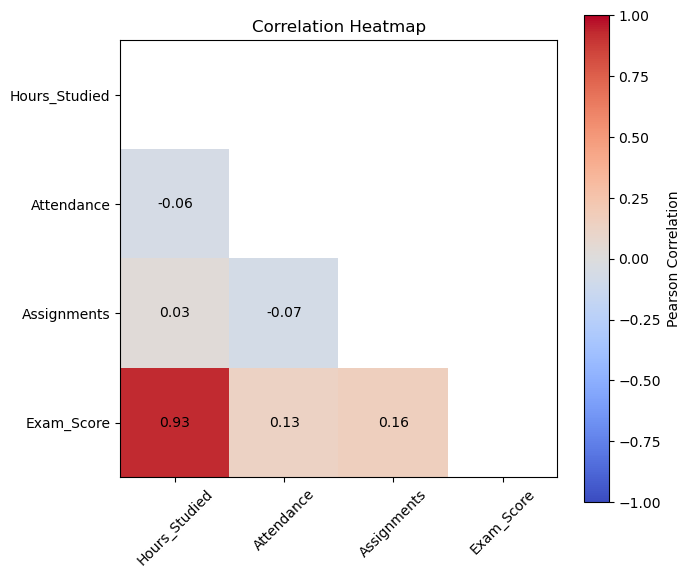

In [5]:
# Create a masked correlation heatmap

corr = df.corr(numeric_only=True)

# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7,6))

heatmap = corr.mask(mask)

plt.imshow(heatmap, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Pearson Correlation")

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if not mask[i, j]:
            plt.text(j, i,
                     f"{corr.iloc[i, j]:.2f}",
                     ha="center",
                     va="center",
                     color="black")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300)

plt.show()

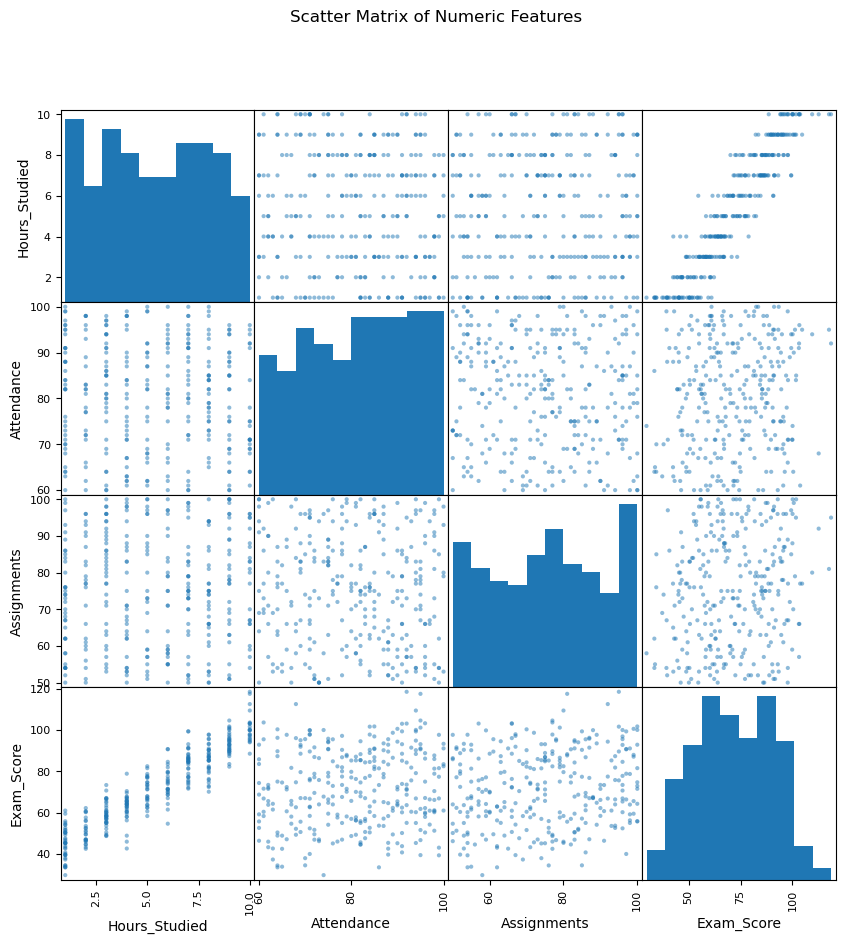

In [6]:
# Scatter Matrix

pd.plotting.scatter_matrix(
    df,
    figsize=(10,10),
    diagonal="hist"
)

plt.suptitle("Scatter Matrix of Numeric Features")

plt.savefig("scatter_matrix.png", dpi=300)

plt.show()

In [7]:
# Display correlation matrix

print(corr)

               Hours_Studied  Attendance  Assignments  Exam_Score
Hours_Studied       1.000000   -0.060743     0.030504    0.927489
Attendance         -0.060743    1.000000    -0.066550    0.125789
Assignments         0.030504   -0.066550     1.000000    0.161384
Exam_Score          0.927489    0.125789     0.161384    1.000000
